In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("BostonHousing.csv")
df.head()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Crime_rate  506 non-null    float64
 1   zn          506 non-null    float64
 2   indus       506 non-null    float64
 3   chas        506 non-null    int64  
 4   nox         506 non-null    float64
 5   rm          501 non-null    float64
 6   Age         506 non-null    float64
 7   Distance    506 non-null    float64
 8   rad         506 non-null    int64  
 9   tax         506 non-null    int64  
 10  ptratio     506 non-null    float64
 11  b           506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            5
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [6]:
df['rm'].fillna(df['rm'].mean(), inplace=True)
df.isnull().sum()

C:\Users\DELL\AppData\Local\Temp\ipykernel_25864\3734160523.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rm'].fillna(df['rm'].mean(), inplace=True)


Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            0
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [7]:
x = df.drop('medv', axis=1)
y=df['medv']

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
# Create a neural network with:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
# model.add(Dense(128, activation='relu'))      # One hidden layer (Dense(128) with ReLU activation).
model.add(Dense(1, activation='linear'))      # One output layer with a linear activation (for regression).

# Compiles the model
model.compile(loss='mae', optimizer='adam', metrics=['mse', 'mae'])

In [ ]:
model.fit(x_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 21.9675 - mae: 21.9675 - mse: 562.7578 - val_loss: 20.1896 - val_mae: 20.1896 - val_mse: 471.2299
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 21.3853 - mae: 21.3853 - mse: 538.1905 - val_loss: 19.6073 - val_mae: 19.6073 - val_mse: 448.6192
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 20.7626 - mae: 20.7626 - mse: 512.1836 - val_loss: 18.8789 - val_mae: 18.8789 - val_mse: 421.4316
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 19.9204 - mae: 19.9204 - mse: 478.9540 - val_loss: 17.8172 - val_mae: 17.8172 - val_mse: 384.1233
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 18.6969 - mae: 18.6969 - mse: 433.4196 - val_loss: 16.3019 - val_mae: 16.3019 - val_mse: 335.0628
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 16.9852 - mae: 16.9852 - mse: 375.8692 - val_loss: 14.3996 - val_mae: 14.3996 - val_mse: 275.2561
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 

In [ ]:
metrics = model.evaluate(x_test, y_test)
metrics

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.2135 - mae: 3.2135 - mse: 32.5087


[3.213505983352661, 32.50874328613281, 3.213505983352661]

In [ ]:
y_pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [ ]:
y_test = np.array(y_test).reshape(-1, 1)

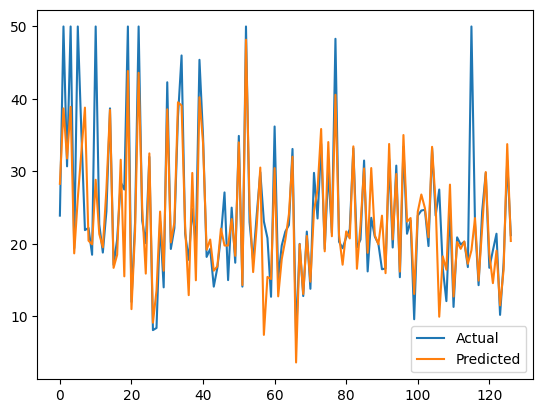

In [ ]:
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()

In [ ]:
print("\n========== MODEL SUMMARY ==========")
model.summary()

print("\n========== DATA SHAPES ==========")
print("X_train shape:", x_train.shape)
print("Y_train shape:", y_train.shape)
print("X_test shape :", x_test.shape)
print("Y_test shape :", y_test.shape)

print("\n========== MODEL INFO ==========")
print("Total layers:", len(model.layers))

print("\n========== HYPERPARAMETERS ==========")
print("Epochs:", 50)
print("Optimizer:", type(model.optimizer).__name__)
print("Learning rate:", model.optimizer.learning_rate.numpy())


========== MODEL SUMMARY ==========


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,029 (35.27 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,020 (23.52 KB)


========== DATA SHAPES ==========
X_train shape: (379, 13)
Y_train shape: (379,)
X_test shape : (127, 13)
Y_test shape : (127, 1)

========== MODEL INFO ==========
Total layers: 3

========== HYPERPARAMETERS ==========
Epochs: 50
Optimizer: Adam
Learning rate: 0.001


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred = model.predict(x_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
MAE: 3.213506083976565
MSE: 32.508741122093475
R2 Score: 0.6795650797216923


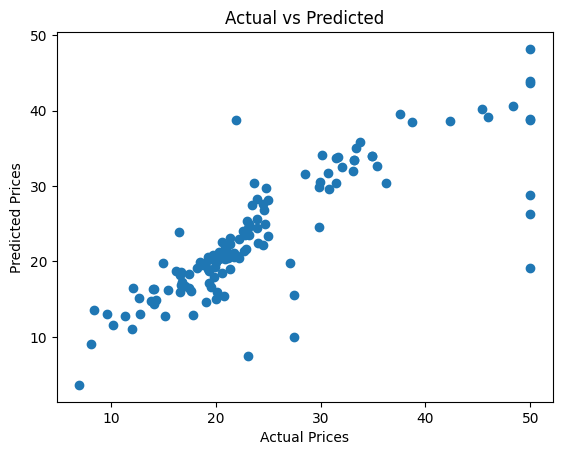

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
sample = [[0.1, 18, 2.3, 0, 0.5, 6.5, 65, 4.0, 1, 300, 15, 390, 5.0]]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("Predicted House Price:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted House Price: 29.210188


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
